# Composition — embeddings in Qdrant

The 50K selection was built from **feature evidence** (identifier banks,
markers, scalar signals). But the router itself will operate on
**embeddings**. This notebook asks two questions the feature-side view
cannot answer:

1. **Does a feature-based fill also produce embedding-space diversity?**
   If our shopping list of features corresponds to real semantic
   variety, the four slices (targeted / no-preference / stat-strata /
   dark-forest) should sit differently in a 2D projection, and the
   no-preference and dark-forest slices should be *broader* than the
   targeted one.
2. **Where dense and sparse retrieval disagree, routing matters.**
   For every query, its top-neighbours under a dense vector and under
   a sparse (BM25) vector need not agree — where they don't, the router
   has a job to do.

The pipeline: upload the 50K to a local Qdrant with two named vector
slots (`dense`, `sparse`), fetch the dense embeddings back for
visualisation, and use Qdrant's own search for near-duplicate and
dense-vs-sparse analyses.

**Prerequisites:**

```bash
docker compose up -d qdrant_cluster        # Qdrant on :6333
poetry install                              # for umap-learn
```

The first upload embeds 50K queries (~10 minutes CPU with bge-small +
BM25). Embeddings are cached to `.embedding_cache/` so re-runs cost
seconds; the collection is skipped when point count already matches.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qdrant_client import QdrantClient

from composition.indexer import (
    DENSE_MODEL_ID,
    SelectionIndexer,
    SelectionQuery,
    default_embeddings,
)
from hybrid_search_rrf_dataset.indexer import EmbeddingCache

QDRANT_URL = "http://localhost:6333"
COLLECTION = "composition_selection"

selection = pd.read_parquet("data/composition/selection.parquet")
print(f"{len(selection):,} queries loaded")
selection[["dataset", "slice", "label_lane", "query"]].head(4)

50,000 queries loaded


,dataset,slice,label_lane,query
0,beir-nfcorpus,A,qrels,DHA
1,beir-nfcorpus,A,qrels,ECMO
2,beir-nfcorpus,A,qrels,Food Dyes and ADHD
3,beir-nfcorpus,A,qrels,Harvard Physicians’ Study II


## Act 1 — upload

The two-slot recipe: **dense** (`BAAI/bge-small-en-v1.5`, 384-dim,
cosine) and **sparse** (`Qdrant/bm25`). Dense captures semantic
similarity; sparse captures lexical overlap — routing pivots on
divergence between the two.

Idempotent: the block checks Qdrant's point count and skips the upload
when the collection is already full. Embeddings live in
`.embedding_cache/`, so `recreate=True` on Qdrant costs seconds, not
minutes, because the vectors don't re-embed.

In [2]:
client = QdrantClient(url=QDRANT_URL)
cache = EmbeddingCache(cache_dir=".embedding_cache")
indexer = SelectionIndexer(
    client=client, collection_name=COLLECTION,
    embeddings=default_embeddings(), cache=cache,
)


def items_from_frame(frame: pd.DataFrame) -> list[SelectionQuery]:
    return [
        SelectionQuery(
            dataset=row.dataset, query_id=str(row.query_id),
            query=row.query, slice=row.slice,
            floors=list(row.floors), checkable=bool(row.checkable),
            label_lane=row.label_lane,
        )
        for row in frame.itertuples(index=False)
    ]


indexer.ensure_collection(recreate=False)
existing = client.count(COLLECTION, exact=True).count
if existing >= len(selection):
    print(f"collection has {existing:,} points -> skip upload")
else:
    print(f"collection at {existing:,} / {len(selection):,} -> uploading...")
    indexer.upload(items_from_frame(selection), batch_size=64)
    print("upload done, cache written:", sorted(Path('.embedding_cache').iterdir()))

client.count(COLLECTION, exact=True)

collection at 0 / 50,000 -> uploading...


embed:sparse: 100%|██████████| 50000/50000 [00:01<00:00, 42659.35it/s]


upload done, cache written: [PosixPath('.embedding_cache/BAAI__bge-small-en-v1.5.dense.pkl'), PosixPath('.embedding_cache/Qdrant__bm25.sparse.pkl')]


CountResult(count=50000)

## Act 2 — semantic diversity by slice

Fetch every dense vector back from Qdrant, project to 2D with UMAP,
and colour three ways.

**What each panel should show, if the feature-based fill is honest:**

- **By slice** — B (no-preference) and D (dark forest) should be
  *broader* than A (targeted): both are meant to be unbiased samples of
  the whole space, while A concentrates on evidence-carrying regions.
- **By dominant floor** — if `id:tech` queries cluster tighter than
  `id:number`, the taxonomy is capturing something semantic and not
  just superficial shape.
- **By dataset** — any region monopolised by one dataset is exactly
  the failure mode the anti-monopoly rule was written to prevent; the
  cap should have kept regions mixed.

The pairwise-distance histogram at the end quantifies "broader": mean
cosine distance within a random 500-query sample per slice.

In [3]:
SLICES = ("A", "B", "C", "D")
records, _ = client.scroll(
    collection_name=COLLECTION, with_vectors=["dense"],
    with_payload=["dataset", "slice", "floors"],
    limit=len(selection),
)
vectors = np.array([r.vector["dense"] for r in records], dtype=np.float32)
payloads = pd.DataFrame([r.payload for r in records])
print(f"fetched {len(vectors):,} dense vectors, shape={vectors.shape}")

fetched 50,000 dense vectors, shape=(50000, 384)


In [4]:
import umap

# 30K sample keeps UMAP under two minutes; the story survives sub-sampling
rng = np.random.default_rng(0)
sample_idx = np.sort(rng.choice(len(vectors), size=min(30_000, len(vectors)),
                                replace=False))
sample_vecs = vectors[sample_idx]
sample_meta = payloads.iloc[sample_idx].reset_index(drop=True)

reducer = umap.UMAP(
    n_components=2, metric="cosine", n_neighbors=30, min_dist=0.1,
    random_state=0,
)
xy = reducer.fit_transform(sample_vecs)
print("UMAP done, layout shape:", xy.shape)

UMAP done, layout shape: (30000, 2)


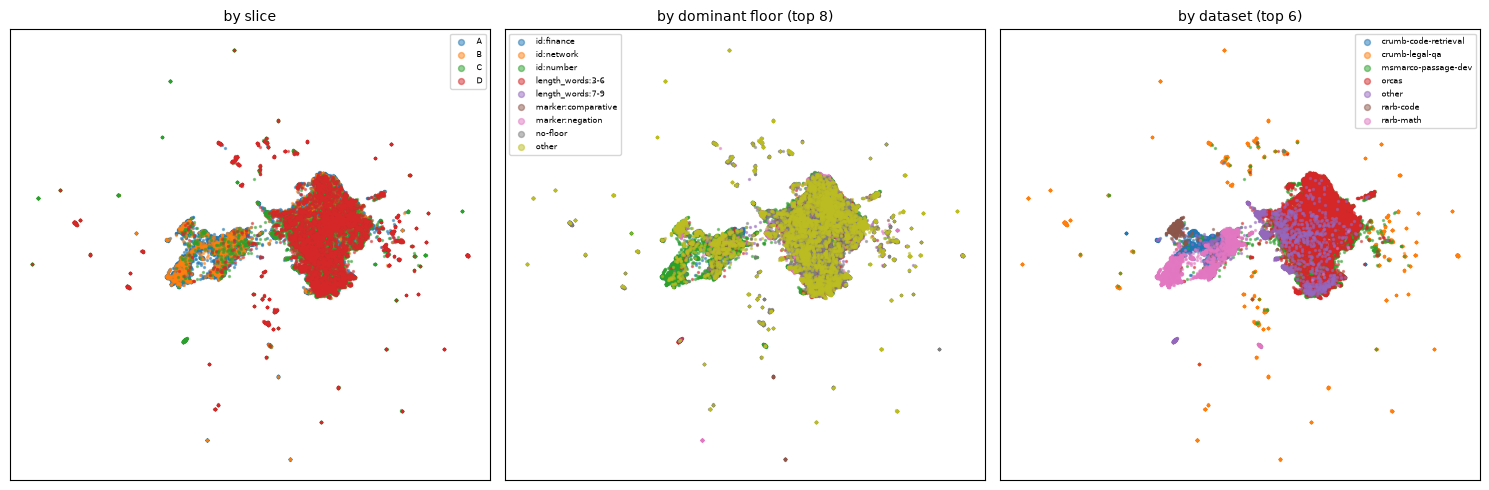

In [5]:
def dominant_floor(floors: list[str]) -> str:
    return sorted(floors)[0] if len(floors) else "no-floor"


sample_meta["dominant_floor"] = sample_meta["floors"].map(dominant_floor)


def scatter_by(ax, colours, title, legend=True):
    for label in sorted(set(colours)):
        m = np.array(colours) == label
        ax.scatter(xy[m, 0], xy[m, 1], s=2, alpha=0.5, label=str(label))
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    if legend:
        ax.legend(fontsize=6, markerscale=3, loc="best")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scatter_by(axes[0], sample_meta["slice"].tolist(), "by slice")
top_floors = sample_meta["dominant_floor"].value_counts().head(8).index
floor_label = sample_meta["dominant_floor"].where(
    sample_meta["dominant_floor"].isin(top_floors), "other")
scatter_by(axes[1], floor_label.tolist(), "by dominant floor (top 8)")
top_ds = sample_meta["dataset"].value_counts().head(6).index
ds_label = sample_meta["dataset"].where(
    sample_meta["dataset"].isin(top_ds), "other")
scatter_by(axes[2], ds_label.tolist(), "by dataset (top 6)")
plt.tight_layout(); plt.show()

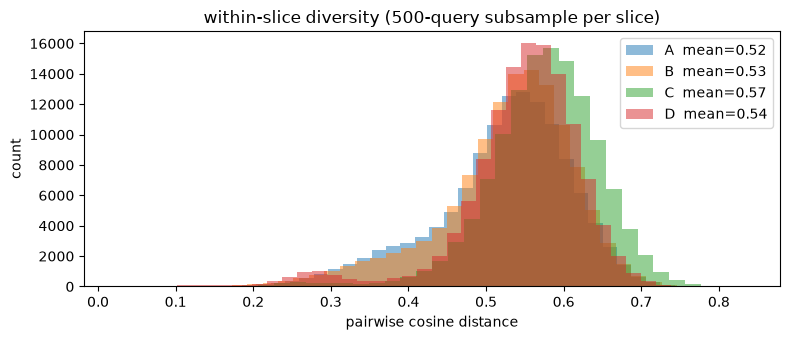

In [6]:
# per-slice mean pairwise cosine distance on a 500-query sample per slice
def sample_pairwise_cosine(vecs: np.ndarray, k: int, seed: int) -> np.ndarray:
    idx = np.random.default_rng(seed).choice(len(vecs), size=k, replace=False)
    v = vecs[idx]
    v /= np.linalg.norm(v, axis=1, keepdims=True) + 1e-12
    sim = v @ v.T
    return 1 - sim[np.triu_indices(k, k=1)]


fig, ax = plt.subplots(figsize=(8, 3.5))
for i, slice_name in enumerate(SLICES):
    slice_mask = payloads["slice"] == slice_name
    if slice_mask.sum() < 500:
        continue
    slice_vecs = vectors[slice_mask.to_numpy()]
    distances = sample_pairwise_cosine(slice_vecs, k=500, seed=0)
    ax.hist(distances, bins=40, alpha=0.5,
            label=f"{slice_name}  mean={distances.mean():.2f}")
ax.set_xlabel("pairwise cosine distance")
ax.set_ylabel("count")
ax.set_title("within-slice diversity (500-query subsample per slice)")
ax.legend()
plt.tight_layout(); plt.show()

## Act 3 — near-duplicates

Overlap between `crumb-code-retrieval`, `rarb-code` and `rarb-math`
would show up here — the feature-side view can't tell paraphrases
apart because both hit the same identifier banks. For a random 2,000
sample we ask Qdrant for each query's top-2 dense neighbour (top-1 is
the query itself) and flag pairs with cosine > 0.95.

In [9]:
import uuid

DUP_THRESHOLD = 0.95
sample = selection.sample(n=2_000, random_state=0).reset_index(drop=True)
seen_pairs = set()
pairs = []
for _, row in sample.iterrows():
    pid = str(uuid.uuid5(uuid.NAMESPACE_DNS, f"{row.dataset}:{row.query_id}"))
    result = client.query_points(
        collection_name=COLLECTION, query=pid, using="dense", limit=2,
        with_payload=["dataset", "query_id", "query", "slice"],
    ).points
    if len(result) < 2 or result[1].score < DUP_THRESHOLD:
        continue
    n = result[1]
    # collapse bidirectional pairs — sort ids so (A,B) and (B,A) become one
    key = tuple(sorted([
        f"{row.dataset}:{row.query_id}",
        f"{n.payload['dataset']}:{n.payload['query_id']}",
    ]))
    if key in seen_pairs:
        continue
    seen_pairs.add(key)
    pairs.append({
        "score": round(n.score, 3),
        "left":  f"{row.dataset}/{row.query_id}",
        "right": f"{n.payload['dataset']}/{n.payload['query_id']}",
        "left_text":  row.query[:80],
        "right_text": n.payload["query"][:80],
        "cross_dataset": row.dataset != n.payload["dataset"],
    })
dup = pd.DataFrame(pairs).sort_values("score", ascending=False)
print(f"{len(dup)} unique near-duplicate PAIRS in a 2K sample")
print(f"  ~{len(dup) * len(selection) // len(sample):,} unique pairs in the full 50K")
print(f"  cross-dataset: {int(dup['cross_dataset'].sum())} / {len(dup)}")
print("\nby dataset (or dataset-pair):")
dup["pair"] = dup.apply(
    lambda r: r["left"].split("/")[0] if not r["cross_dataset"]
    else " <-> ".join(sorted([r["left"].split("/")[0], r["right"].split("/")[0]])),
    axis=1)
print(dup["pair"].value_counts().to_string())
dup.head(10)

111 unique near-duplicate PAIRS in a 2K sample
  ~2,775 unique pairs in the full 50K
  cross-dataset: 1 / 111

by dataset (or dataset-pair):
pair
crumb-legal-qa                                    90
rarb-code                                         10
rarb-math                                          6
quest                                              2
orcas                                              1
crumb-set-operation-entity-retrieval <-> quest     1
msmarco-passage-dev                                1


,score,left,right,left_text,right_text,cross_dataset,pair
13,0.989,orcas/5042871,orcas/7167419,is lyft or uber better,is lyft better than uber,False,orcas
40,0.987,crumb-legal-qa/5556,crumb-legal-qa/5557,Secondary methods of service are defined as th...,Secondary methods of service are defined as th...,False,crumb-legal-qa
86,0.987,crumb-legal-qa/5352,crumb-legal-qa/5353,Secondary methods of service are defined as th...,Secondary methods of service are defined as th...,False,crumb-legal-qa
33,0.984,crumb-legal-qa/5259,crumb-legal-qa/5262,Primary methods of service are defined as thos...,Primary methods of service are defined as thos...,False,crumb-legal-qa
18,0.984,crumb-legal-qa/6652,crumb-legal-qa/7132,"In an eviction action, can a tenant rebut/rais...","In an eviction action, can a tenant rebut/rais...",False,crumb-legal-qa
35,0.983,crumb-legal-qa/5082,crumb-legal-qa/5079,Primary methods of service are defined as thos...,Primary methods of service are defined as thos...,False,crumb-legal-qa
16,0.983,rarb-code/humanevalpack-q-538,rarb-code/humanevalpack-q-702,Finish the following code based on the docstri...,Finish the following code based on the docstri...,False,rarb-code
0,0.982,quest/test-579,crumb-set-operation-entity-retrieval/f876a6c39...,1934 British novels not set in Europe,1934 British novels not set in the United Kingdom,True,crumb-set-operation-entity-retrieval <-> quest
27,0.982,rarb-code/humanevalpack-q-457,rarb-code/humanevalpack-q-621,Finish the following code based on the docstri...,Finish the following code based on the docstri...,False,rarb-code
46,0.982,crumb-legal-qa/5757,crumb-legal-qa/5862,Secondary methods of service are defined as th...,Secondary methods of service are defined as th...,False,crumb-legal-qa


## Act 4 — where dense and sparse disagree

For every query in a small sample: top-10 nearest neighbours under
`dense`, top-10 under `sparse`. Jaccard overlap of the two id sets
gives one number per query — low overlap = the two retrievers see this
query differently = the router has a real job to do.

Expected pattern from the composition doctrine: **identifier-carrying
queries (slice A, targeted) show lower agreement** than the plain-NL
statistical strata (slice C), because identifiers are exactly what
BM25 latches onto and dense embeddings smooth over.

       count  mean   std  min  25%   50%   75%   max
slice                                               
A      478.0  0.09  0.12  0.0  0.0  0.05  0.11  0.82
B      134.0  0.09  0.13  0.0  0.0  0.05  0.11  0.67
C      200.0  0.06  0.11  0.0  0.0  0.00  0.06  0.82
D      188.0  0.15  0.21  0.0  0.0  0.05  0.25  1.00


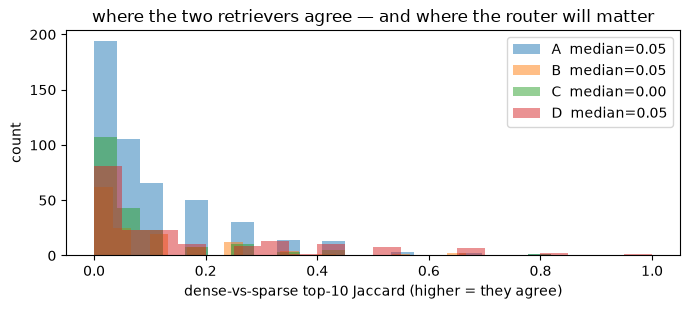

In [8]:
import uuid

sample = selection.sample(n=1_000, random_state=1).reset_index(drop=True)
rows = []
for _, row in sample.iterrows():
    pid = str(uuid.uuid5(uuid.NAMESPACE_DNS, f"{row.dataset}:{row.query_id}"))
    dense = client.query_points(
        collection_name=COLLECTION, query=pid, using="dense", limit=11,
    ).points
    sparse = client.query_points(
        collection_name=COLLECTION, query=pid, using="sparse", limit=11,
    ).points
    dense_ids = {p.id for p in dense[1:]}
    sparse_ids = {p.id for p in sparse[1:]}
    union = dense_ids | sparse_ids
    jaccard = (len(dense_ids & sparse_ids) / len(union)) if union else 0.0
    rows.append({"slice": row.slice, "jaccard": jaccard})
disagreement = pd.DataFrame(rows)
print(disagreement.groupby("slice")["jaccard"].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 3.2))
for slice_name in sorted(disagreement["slice"].unique()):
    values = disagreement[disagreement["slice"] == slice_name]["jaccard"]
    ax.hist(values, bins=20, alpha=0.5,
            label=f"{slice_name}  median={values.median():.2f}")
ax.set_xlabel("dense-vs-sparse top-10 Jaccard (higher = they agree)")
ax.set_ylabel("count"); ax.set_title(
    "where the two retrievers agree — and where the router will matter"
)
ax.legend()
plt.tight_layout(); plt.show()

## Takeaways

Three assumption-checks the notebook made observable:

1. **Slice geometry** — if B and D really are broader than A in the
   pairwise-distance histogram, the "unbiased control" and "dark forest"
   slices are doing their job. If they look identical to A, the
   composition machinery leaked its own bias into what was meant to be
   free of it.
2. **Duplicate risk** — an above-noise near-duplicate rate would
   contradict "50K distinct training rows"; the feature-side fill would
   need a post-hoc dedup step (Qdrant search filtered by
   `label_lane`/`slice` is the cheapest form).
3. **Router opportunity** — Act 4's Jaccard-per-slice tells us
   *quantitatively* where routing has room to help. Low agreement on
   slice A (identifier queries) with high agreement on slice C
   (plain-NL) would confirm the classical intuition; anything else is a
   finding.

None of these turn back to change the composition itself — they inform
the labeling stage next, which needs to run retrievals against a real
corpus to derive per-query strategy labels.
